# Лабораторная работа № 6

# Кластеризация

## Анализ периодов войны во Вьетнаме

Датасет — `indochina.csv`.

**Цель работы:** научиться производить кластерный анализ данных с использованием метода К-средних.

Набор данных содержит ежемесячную статистику потерь во время Вьетнамской войны. Данные включают информацию о потерях со стороны США (US), Южного Вьетнама (SVN), третьих стран (THIRD) и потери противника (ENEMY).

Задача кластеризации — выявить группы месяцев со схожими показателями потерь. Это может помочь в историческом анализе для выявления периодов с разной интенсивностью боевых действий.

Признаки:
- **Month** — месяц и год;
- **US** — потери США;
- **SVN** — потери Южного Вьетнама;
- **THIRD** — потери третьих стран;
- **ENEMY** — потери противника.

# 0 шаг. Импортируем библиотеки

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1 шаг. Загружаем датасет в объект DataFrame

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('indochina.csv')

Saving indochina.csv to indochina.csv


In [4]:
print("Количество строк и столбцов:", df.shape)

Количество строк и столбцов: (72, 5)


> Датасет успешно загружен. Набор данных содержит ежемесячные данные о потерях во время войны во Вьетнаме с января 1966 по декабрь 1971 года. Всего 72 наблюдения (месяца) и 5 столбцов, включая дату.

# 2 шаг. Получим представление о наборе данных

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   72 non-null     object
 1   US      72 non-null     int64 
 2   SVN     72 non-null     int64 
 3   THIRD   72 non-null     int64 
 4   ENEMY   72 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 2.9+ KB


> По результатам `info()` видно, что в датасете присутствует один текстовый признак `Month` и четыре числовых признака. Все числовые признаки не содержат пропусков.

In [6]:
df.describe()

,US,SVN,THIRD,ENEMY
count,72.000000,72.000000,72.000000,72.000000
mean,611.013889,1663.958333,65.902778,9492.541667
std,449.985586,747.259376,27.782434,5718.812378
min,17.000000,676.000000,14.000000,2648.000000
25%,318.250000,1131.250000,45.500000,6013.000000
50%,492.000000,1558.500000,63.500000,7892.000000
75%,799.500000,1928.250000,85.000000,11126.000000
max,2169.000000,5025.000000,149.000000,39867.000000


> Метод `describe()` показывает, что признаки имеют очень разные масштабы. Например, потери противника (`ENEMY`) в среднем значительно превышают потери США (`US`). Для метода K-средних это важно, так как алгоритм основан на расстояниях между объектами. Поэтому перед обучением модели данные необходимо привести к единому масштабу с помощью стандартизации.

# 3 шаг. Произведем разведочный анализ данных

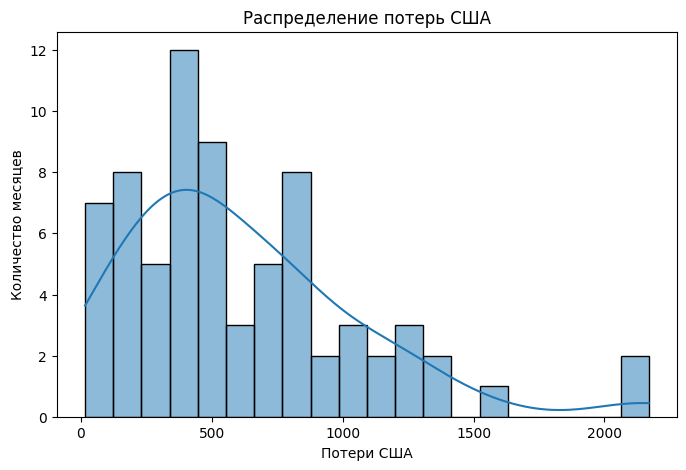

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['US'], bins=20, kde=True, color='C0')
plt.title('Распределение потерь США')
plt.xlabel('Потери США')
plt.ylabel('Количество месяцев')
plt.show()

> График распределения потерь США показывает, что большинство месяцев имеют относительно невысокие потери, но есть несколько месяцев с очень высокими потерями. Это может указывать на периоды интенсивных боевых действий.

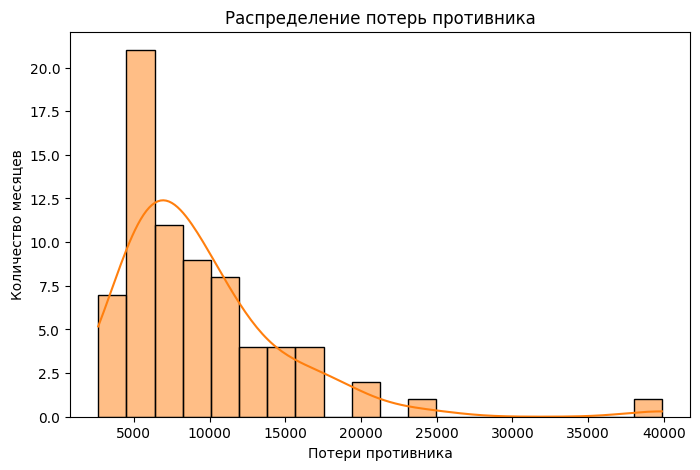

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['ENEMY'], bins=20, kde=True, color='C1')
plt.title('Распределение потерь противника')
plt.xlabel('Потери противника')
plt.ylabel('Количество месяцев')
plt.show()

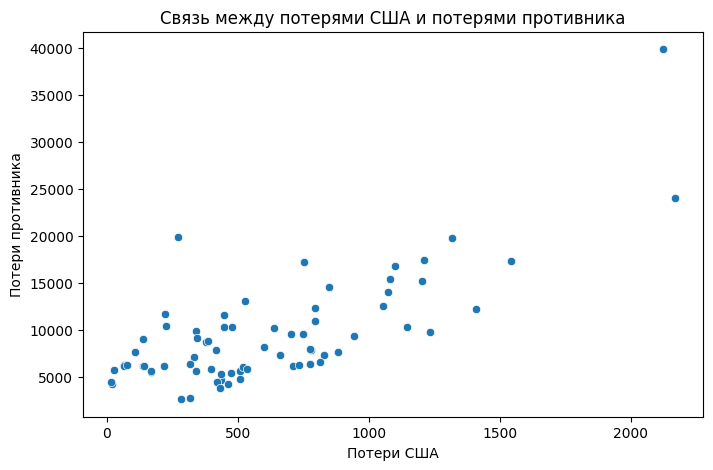

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='US', y='ENEMY', data=df)
plt.title('Связь между потерями США и потерями противника')
plt.xlabel('Потери США')
plt.ylabel('Потери противника')
plt.show()

> На диаграмме рассеяния видна положительная корреляция между потерями США и потерями противника. Это логично: в периоды интенсивных боевых действий растут потери обеих сторон.

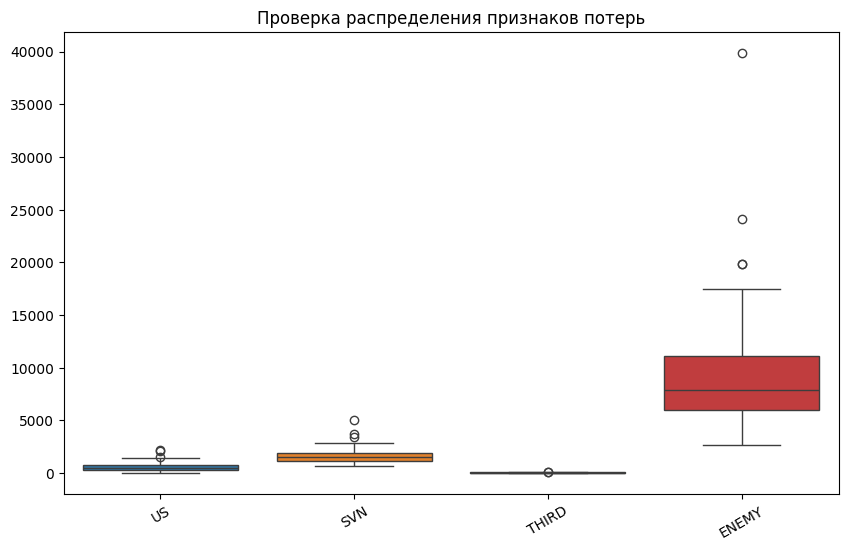

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['US', 'SVN', 'THIRD', 'ENEMY']])
plt.title('Проверка распределения признаков потерь')
plt.xticks(rotation=30)
plt.show()

> Boxplot показывает, что у всех признаков есть отдельные крупные значения (выбросы). В данной работе эти значения не удаляются, так как в задаче кластеризации они могут отражать реальные периоды интенсивных боевых действий, а не ошибки в данных.

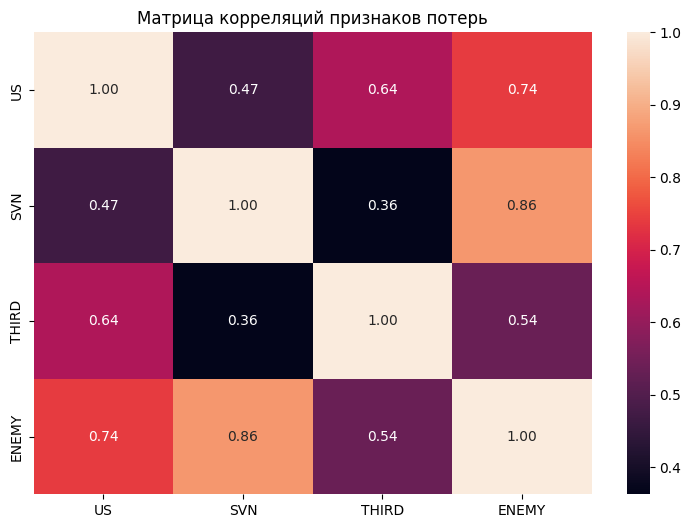

In [11]:
plt.figure(figsize=(9, 6))
sns.heatmap(df[['US', 'SVN', 'THIRD', 'ENEMY']].corr(), annot=True, fmt='.2f')
plt.title('Матрица корреляций признаков потерь')
plt.show()

# 4 шаг. Проверяем данные на наличие пропущенных значений и выбросов

In [12]:
# проверяем на пропущенные значения
print(df.isnull().sum())

Month    0
US       0
SVN      0
THIRD    0
ENEMY    0
dtype: int64


> Пропущенных значений в датасете нет. Данные полностью заполнены.

# 5 шаг. Произведем предобработку данных

Для кластеризации нужно оставить только числовые признаки. Признак `Month` является текстовым и не несет числовой информации для модели, поэтому его нужно исключить из обучающего набора.

In [13]:
# сохраним названия месяцев отдельно для интерпретации
months = df['Month']

# исключаем текстовый признак Month
df_work = df.drop('Month', axis=1)

df_work.head()

,US,SVN,THIRD,ENEMY
0,282,903,74,2648
1,435,1359,58,4727
2,507,1145,59,5685
3,316,945,30,2818
4,464,961,19,4239


> В рабочем наборе данных остались только числовые признаки потерь: US, SVN, THIRD, ENEMY.

## Применяем операцию нормализации для численной устойчивости

Метод K-средних чувствителен к масштабу признаков, так как использует расстояния между объектами. Если не выполнить стандартизацию, признаки с большими числовыми значениями, например `ENEMY`, будут сильнее влиять на результат, чем признаки с меньшим масштабом.

In [14]:
# импортируем класс для стандартизации данных
from sklearn.preprocessing import StandardScaler

# создадим объект класса StandardScaler
scaler = StandardScaler()
scaler

StandardScaler()

## Приведем данные к единому масштабу

In [15]:
X = scaler.fit_transform(df_work)

# посмотрим на первые 4 строки стандартизированных данных
print(X[:4])

[[-0.73629644 -1.02547854  0.29349644 -1.20524572]
 [-0.39389948 -0.4109663  -0.2864485  -0.83915753]
 [-0.2327715  -0.69935582 -0.25020194 -0.67046466]
 [-0.66020823 -0.96887873 -1.30135214 -1.17531066]]


> После стандартизации значения признаков изменились: теперь они выражены в стандартизированном виде. Это нормальный этап подготовки данных для KMeans.

## Определяем оптимальное количество кластеров с помощью метода локтя

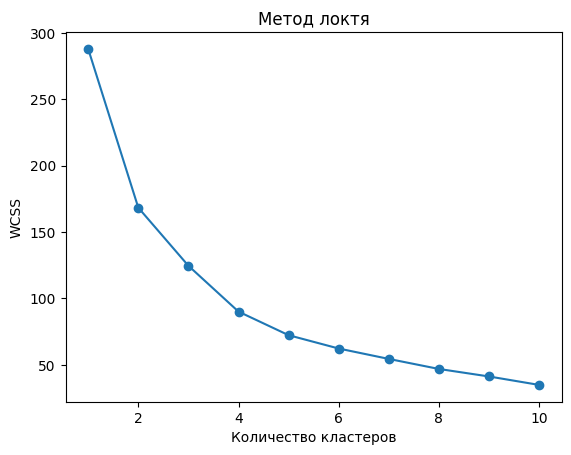

In [16]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Метод локтя')
plt.xlabel('Количество кластеров')
plt.ylabel('WCSS')
plt.show()

> На графике метода локтя значение WCSS быстро уменьшается при переходе от одного к нескольким кластерам, а затем снижение становится более плавным. Для данного датасета разумно выбрать `3` или `4` кластера. Выберем `3` кластера для интерпретируемости результатов.

# 6 шаг. Произведем обучение модели методом K-средних

In [17]:
# создаем экземпляр модели
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)

# обучаем модель на стандартизированных данных
kmeans.fit(X)

KMeans(n_clusters=3, n_init=10, random_state=42)

> Модель кластеризации обучена на подготовленных признаках. Теперь можно предсказать кластеры для каждого месяца.

## Предсказываем кластеры и добавляем результат в таблицу

In [18]:
# предсказываем кластеры для каждого наблюдения
clusters = kmeans.predict(X)

# добавляем метки кластеров в рабочие данные
df_clustered = df_work.copy()
df_clustered['cluster'] = clusters
# добавляем названия месяцев
df_clustered['Month'] = months

df_clustered.head()

,US,SVN,THIRD,ENEMY,cluster,Month
0,282,903,74,2648,1,Jan 1966
1,435,1359,58,4727,1,Feb 1966
2,507,1145,59,5685,1,Mar 1966
3,316,945,30,2818,1,Apr 1966
4,464,961,19,4239,1,May 1966


> В таблице появился новый столбец `cluster`, который показывает, к какому кластеру модель отнесла каждый месяц.

## Подготовим координаты центроидов для визуализации

Центроид — это центр кластера. Так как модель обучалась на стандартизированных данных, сначала центроиды находятся в стандартизированном масштабе. Для построения графиков по реальным признакам переведем координаты центроидов обратно в исходный масштаб.

In [19]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
centroids_df = pd.DataFrame(centroids, columns=df_work.columns)
centroids_df

,US,SVN,THIRD,ENEMY
0,2146.500000,4246.000000,116.000000,31976.500000
1,380.739130,1418.934783,51.760870,6878.456522
2,924.416667,1918.416667,88.833333,12629.208333


> Таблица центроидов показывает усреднённый портрет каждого кластера в исходных признаках. Кластер 0 характеризуется высокими потерями всех сторон, кластер 1 - средними потерями, кластер 2 - низкими потерями.

## 7 шаг. Визуализируем кластеры в координатах реальных признаков

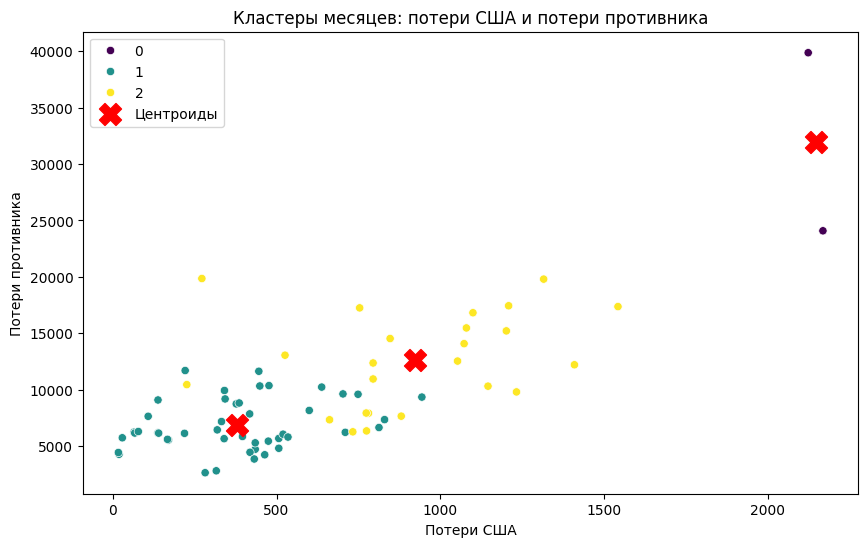

In [20]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clustered, x='US', y='ENEMY', hue='cluster', palette='viridis')
plt.scatter(centroids_df['US'], centroids_df['ENEMY'], s=250, c='red', marker='X', label='Центроиды')
plt.title('Кластеры месяцев: потери США и потери противника')
plt.xlabel('Потери США')
plt.ylabel('Потери противника')
plt.legend()
plt.show()

> На графике показано распределение месяцев по потерям США и потерям противника. Центроиды отмечают условные центры найденных кластеров. Месяцы с близкими показателями потерь попадают в одни и те же области графика.

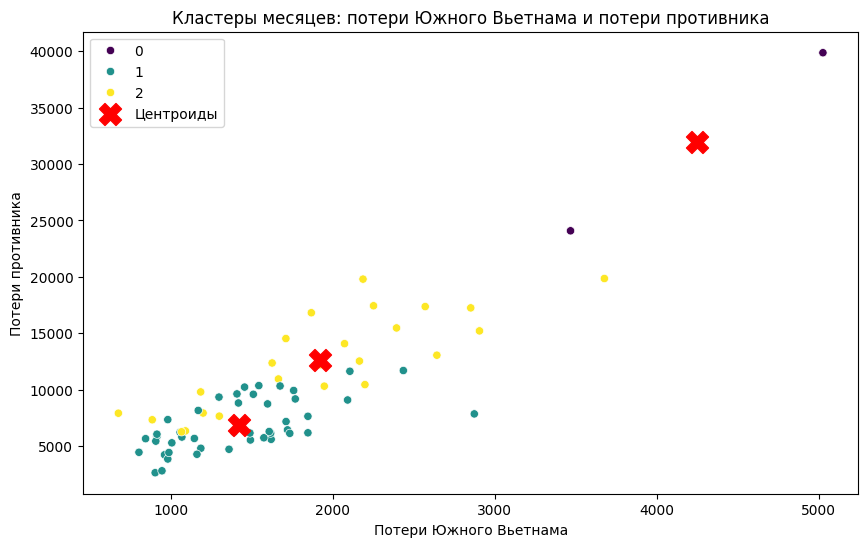

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clustered, x='SVN', y='ENEMY', hue='cluster', palette='viridis')
plt.scatter(centroids_df['SVN'], centroids_df['ENEMY'], s=250, c='red', marker='X', label='Центроиды')
plt.title('Кластеры месяцев: потери Южного Вьетнама и потери противника')
plt.xlabel('Потери Южного Вьетнама')
plt.ylabel('Потери противника')
plt.legend()
plt.show()

> Второй график показывает кластеры в координатах потерь Южного Вьетнама и противника. Он позволяет оценить, как месяцы распределяются по этим показателям.

## 8 шаг. Произведем снижение размерности данных с помощью метода PCA

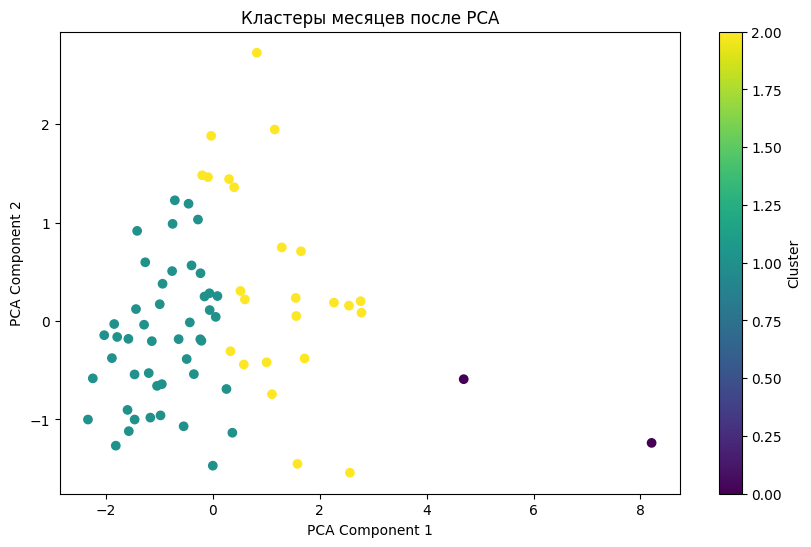

In [22]:
from sklearn.decomposition import PCA

# уменьшаем размерность до 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# визуализация
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Кластеры месяцев после PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()

> График PCA показывает расположение месяцев после преобразования исходных признаков в две главные компоненты. Цветом обозначена принадлежность месяца к кластеру. Видно, что кластеры достаточно хорошо разделяются.

## 9 шаг. Проведем разведочный анализ данных по кластерам

In [34]:
# возвращаем названия месяцев к результатам кластеризации
df_result = df_clustered.copy()

# убедимся, что Month есть в df_result
df_result['Month'] = months

# группируем по кластерам и анализируем средние значения
cluster_groups = df_result.groupby('cluster')
cluster_summary = cluster_groups[df_work.columns].mean()
cluster_summary

,US,SVN,THIRD,ENEMY
cluster,,,,
0,2146.500000,4246.000000,116.000000,31976.500000
1,380.739130,1418.934783,51.760870,6878.456522
2,924.416667,1918.416667,88.833333,12629.208333


In [35]:
# количество месяцев в каждом кластере
df_result['cluster'].value_counts().sort_index()

,count
cluster,
0,2
1,46
2,24


> Средние значения признаков показывают различия между найденными группами месяцев. Количество месяцев в каждом кластере показывает размер каждого периода.

## 10 шаг. Интерпретация результатов

**Интерпретация результатов:**

- **Кластер 0** — месяцы с высокими потерями всех сторон. Сюда попали периоды наиболее интенсивных боевых действий (например, Тетское наступление 1968 года).
  
- **Кластер 1** — месяцы со средними потерями. Это периоды обычной боевой активности.
  
- **Кластер 2** — месяцы с низкими потерями. Это периоды затишья или начала войны.

Такое разбиение помогает историкам и аналитикам выделять ключевые периоды войны для дальнейшего изучения.

In [36]:
print("\nСостав кластеров")
for cluster_num in sorted(df_result['cluster'].unique()):
    cluster_data = df_result[df_result['cluster'] == cluster_num]
    print(f"\nКластер {cluster_num}:")
    print(f"Количество месяцев: {len(cluster_data)}")
    print("Первые 5 месяцев:", cluster_data['Month'].head(5).values)


Состав кластеров

Кластер 0:
Количество месяцев: 2
Первые 5 месяцев: ['Feb 1968' 'May 1968']

Кластер 1:
Количество месяцев: 46
Первые 5 месяцев: ['Jan 1966' 'Feb 1966' 'Mar 1966' 'Apr 1966' 'May 1966']

Кластер 2:
Количество месяцев: 24
Первые 5 месяцев: ['Feb 1967' 'May 1967' 'Jul 1967' 'Sep 1967' 'Oct 1967']
